<a href="https://colab.research.google.com/github/dot11atwit/lungdiseaseindividualproject/blob/main/Lung_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing the Data

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

data = pd.read_csv("lung_disease_data.csv") # Reads the file.
data = data.rename(columns={"Smoking Status": "Smoker"}) # Changes the name of the column
data.dropna(inplace=True) # Drops "Nan" or missing information
data.head()

,Age,Gender,Smoker,Lung Capacity,Disease Type,Treatment Type,Hospital Visits,Recovered
0,71.0,Female,No,4.49,COPD,Therapy,14.0,Yes
5,22.0,Female,No,3.65,Bronchitis,Medication,11.0,Yes
6,41.0,Male,Yes,2.98,Asthma,Medication,12.0,Yes
8,21.0,Female,No,4.05,Lung Cancer,Medication,12.0,No
9,49.0,Male,Yes,5.70,Pneumonia,Medication,11.0,Yes


In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3236 entries, 0 to 5199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              3236 non-null   float64
 1   Gender           3236 non-null   object 
 2   Smoker           3236 non-null   object 
 3   Lung Capacity    3236 non-null   float64
 4   Disease Type     3236 non-null   object 
 5   Treatment Type   3236 non-null   object 
 6   Hospital Visits  3236 non-null   float64
 7   Recovered        3236 non-null   object 
dtypes: float64(3), object(5)
memory usage: 227.5+ KB


#Cleaning Data

In [61]:
data.drop(["Gender", "Disease Type", "Treatment Type", "Hospital Visits", "Recovered", "Smoker"], inplace=True, axis=1) # Drops the data not needed for the model.

data.head()


,Age,Lung Capacity
0,71.0,4.49
5,22.0,3.65
6,41.0,2.98
8,21.0,4.05
9,49.0,5.70


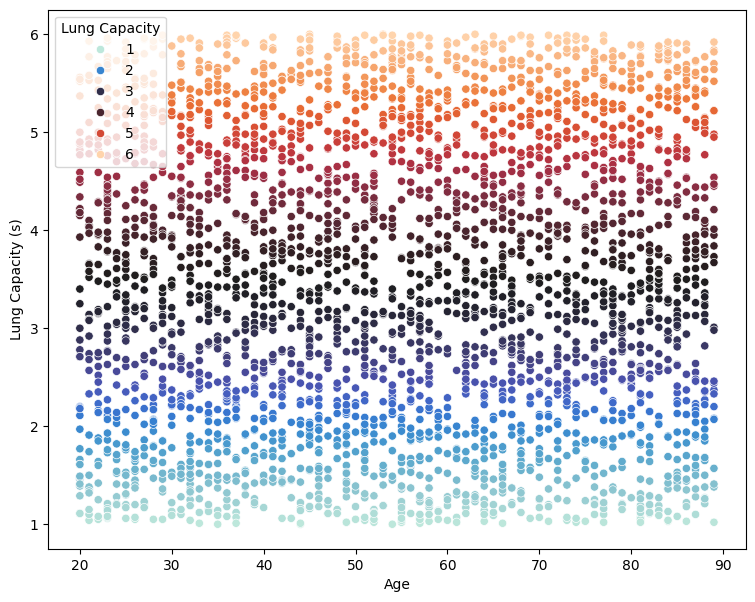

In [62]:
plt.figure(figsize=(9, 7)) # Figure size

sns.scatterplot(data=data, x='Age', y='Lung Capacity', hue='Lung Capacity', palette='icefire')

# Convert 'Age' column to categorical data type
data["Age"] = data["Age"].astype("category", copy=False)

# Convert 'Lung Capacity' column to categorical data type
data["Lung Capacity"] = data["Lung Capacity"].astype("category", copy=False)

plt.ylabel("Lung Capacity (s)")

plt.show()


In [63]:
y = data["Lung Capacity"]
X = data.drop("Lung Capacity", axis=1)

#Normalizing Data

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() ## Create a scaler object

X_scaled = scaler.fit_transform(X) # Fit the scaler to the data and transform the data



In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [66]:

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

#Results

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred) # Mean Squared Error

rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error

print(f"MSE: {mse:.4f}") # Measures the predicted and actual target of the dataset
print(f"RMSE: {rmse:.4f}") # Measures the average difference between the values

MSE: 2.1977
RMSE: 1.4825
